In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime as dt

In [2]:
os.listdir('../data/raw/')

['.ipynb_checkpoints',
 '1STUD_batch_20260615_220936.json',
 '1STUD_batch_20260616_120929.json',
 '1STUD_batch_20260616_125913.json',
 '1STUD_batch_20260629_221901.json',
 'AsmonTV_batch_20260608_205250.json',
 'AsmonTV_batch_20260615_220936.json',
 'Aztecross_batch_20260616_120929.json',
 'Aztecross_batch_20260616_125913.json',
 'BandaiNamcoAmerica_batch_20260616_120929.json',
 'BandaiNamcoAmerica_batch_20260616_125913.json',
 'CallofDuty_batch_20260615_220936.json',
 'CallofDuty_batch_20260616_120929.json',
 'CallofDuty_batch_20260616_125913.json',
 'CaptainSparklez_batch_20260615_220936.json',
 'CaptainSparklez_batch_20260616_120929.json',
 'CaptainSparklez_batch_20260616_125913.json',
 'CaptainSparklez_batch_20260629_221901.json',
 'CoryxKenshin_batch_20260608_205250.json',
 'CoryxKenshin_batch_20260615_220936.json',
 'dewyroblox_batch_20260615_220936.json',
 'dream_batch_20260608_205250.json',
 'FlameFragsMC_batch_20260608_205250.json',
 'FlameFragsMC_batch_20260615_220936.json',


In [5]:
dfs = []
for file in os.listdir('../data/raw/'):
    if (file != '.ipynb_checkpoints') and (file != 'scraped_videos_tracker.json'):
        dftemp = pd.read_json('../data/raw/'+file)
        dftemp['channel'] = file.split('_')[0]
        dfs+= [dftemp]
df = pd.concat(dfs)

In [6]:
import re

def tokenize(text):
    text = text.lower()
    return re.findall(r"\b[a-z0-9]+\b", text)

df['tokens'] = df['text'].apply(tokenize)

In [22]:
df.channel.value_counts()

channel
AsmonTV               99995
MrLololoshka          99995
CoryxKenshin          99861
IShowSpeed            99799
markiplier            99796
1STUD                 98858
CaptainSparklez       94275
penguinz0             88764
GameTheory            88203
leagueoflegends       87911
Technoblade           84587
NintendoAmerica       83902
KreekCraft            83885
xQcOW                 83155
PlayStation           65423
CallofDuty            51488
RockstarGames         40506
GamersNexus           39999
JennyDevil            39198
ItsUzoth              35300
dream                 30394
Aztecross             28862
wifies                27926
MrBeastGaming         17495
dewyroblox            17010
BandaiNamcoAmerica    15387
FlameFragsMC          10488
Spokeishere           10299
ParrotX2               9958
Kreek                  3112
Marlowww               1800
HaiperAlso             1697
Name: count, dtype: int64

Below I am checking the frequency of comments over time

C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\1121114334.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df.groupby(df["published_at"].dt.to_period("W"))


Weekly Comment Statistics
Mean:     1844.46
Median:   520.00
Min:      1
Max:      30637
Std Dev:  3605.75


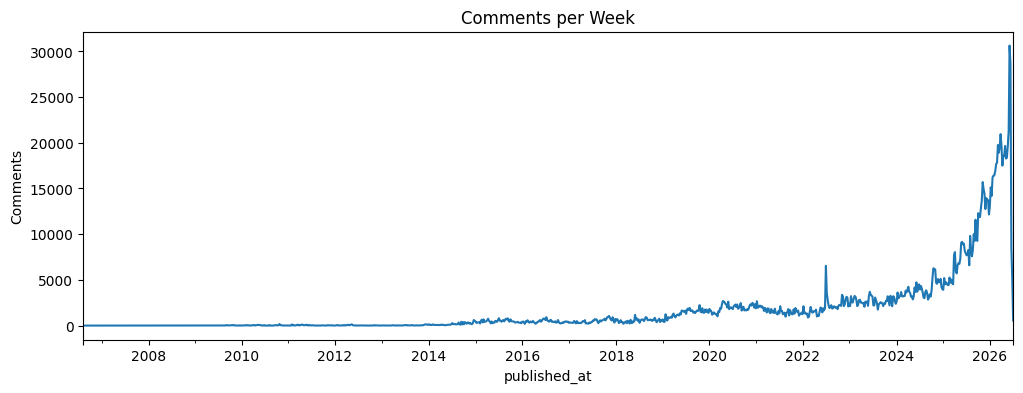

In [15]:
weekly_counts = (
    df.groupby(df["published_at"].dt.to_period("W"))
      .size()
)

print("Weekly Comment Statistics")
print(f"Mean:     {weekly_counts.mean():.2f}")
print(f"Median:   {weekly_counts.median():.2f}")
print(f"Min:      {weekly_counts.min()}")
print(f"Max:      {weekly_counts.max()}")
print(f"Std Dev:  {weekly_counts.std():.2f}")


weekly_counts.plot(figsize=(12,4))
plt.title("Comments per Week")
plt.ylabel("Comments")
plt.show()

I do the same per channel

Weekly Comment Statistics
Mean:     549.21
Median:   545.50
Min:      5
Max:      1290
Std Dev:  276.31


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


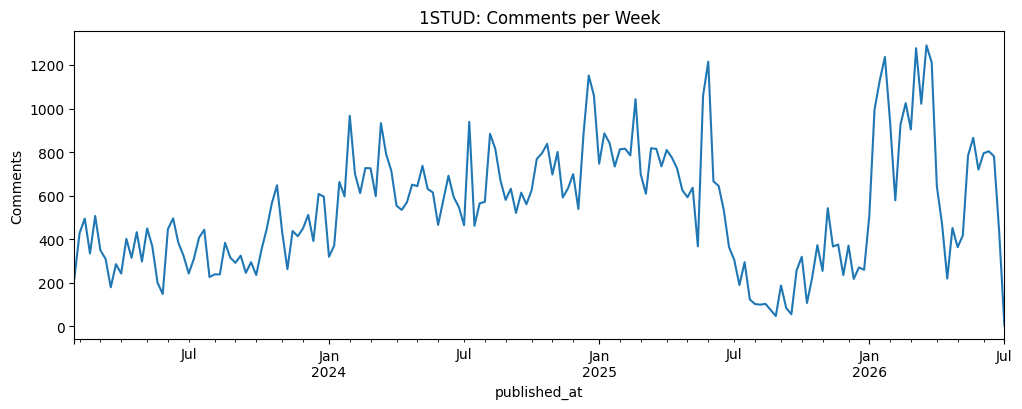

Weekly Comment Statistics
Mean:     2272.61
Median:   2477.50
Min:      42
Max:      3259
Std Dev:  862.98


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


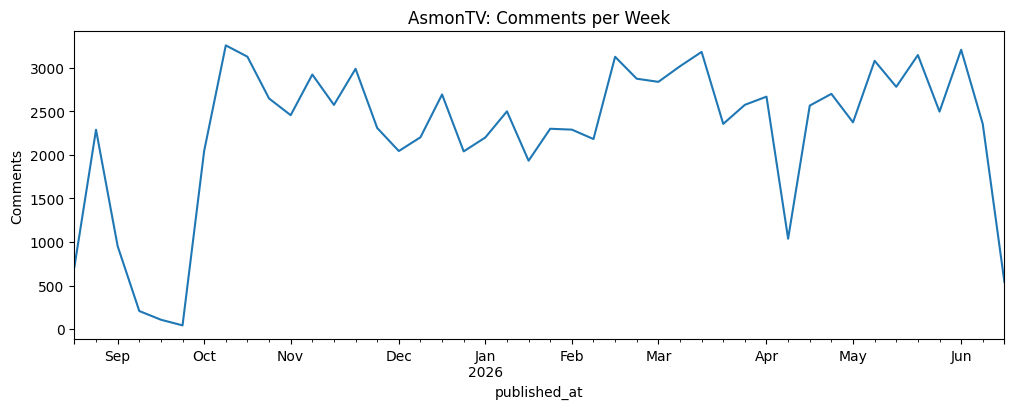

Weekly Comment Statistics
Mean:     1924.13
Median:   2012.00
Min:      68
Max:      3311
Std Dev:  746.70


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


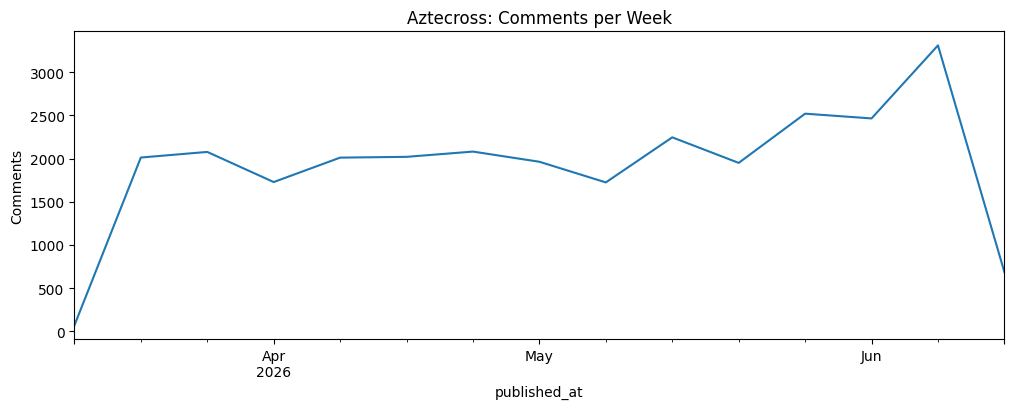

Weekly Comment Statistics
Mean:     439.63
Median:   344.00
Min:      155
Max:      990
Std Dev:  213.77


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


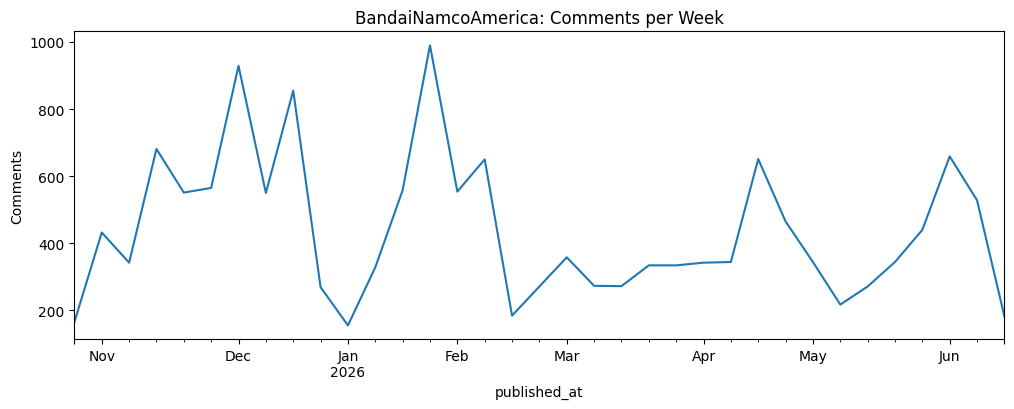

Weekly Comment Statistics
Mean:     415.23
Median:   344.50
Min:      33
Max:      1705
Std Dev:  311.43


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


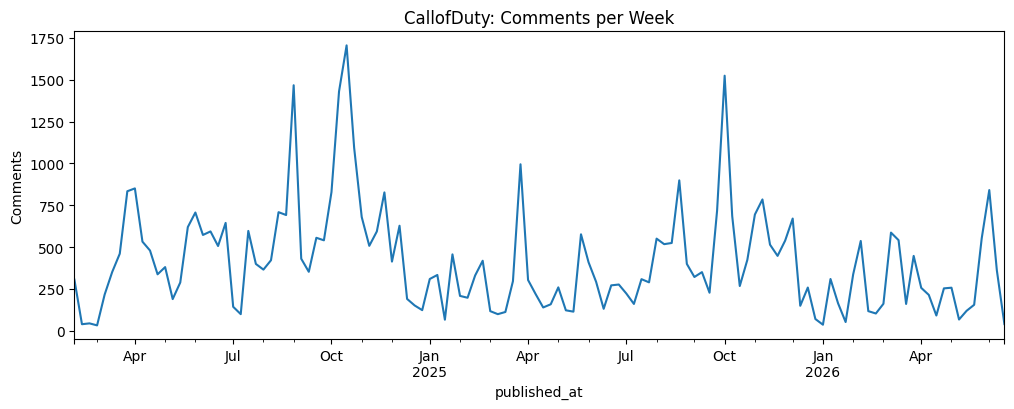

Weekly Comment Statistics
Mean:     253.43
Median:   192.50
Min:      1
Max:      841
Std Dev:  232.02


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


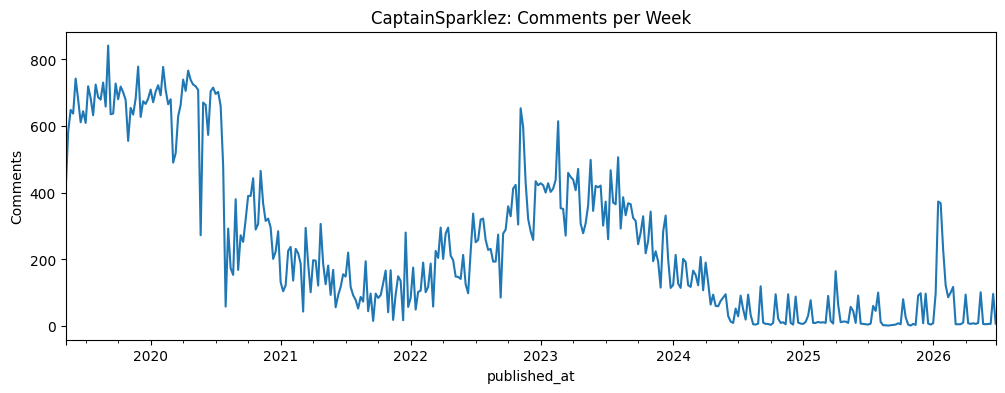

Weekly Comment Statistics
Mean:     175.19
Median:   128.00
Min:      17
Max:      879
Std Dev:  147.66


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


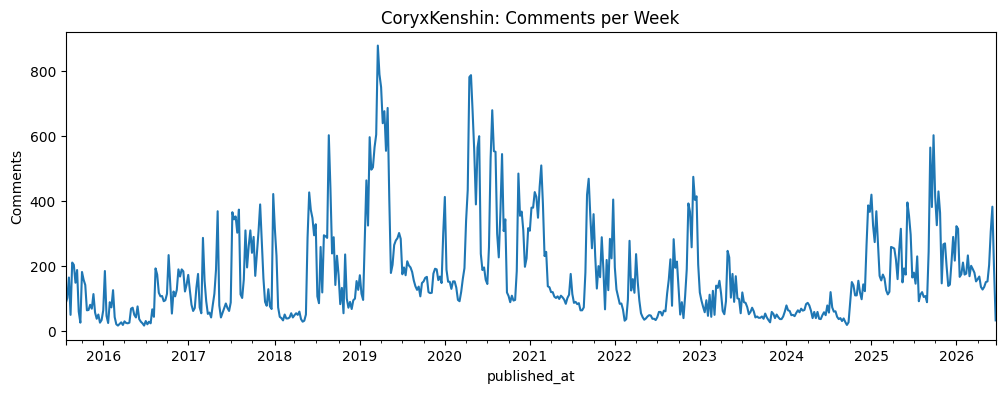

Weekly Comment Statistics
Mean:     104.36
Median:   81.00
Min:      1
Max:      458
Std Dev:  96.00


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


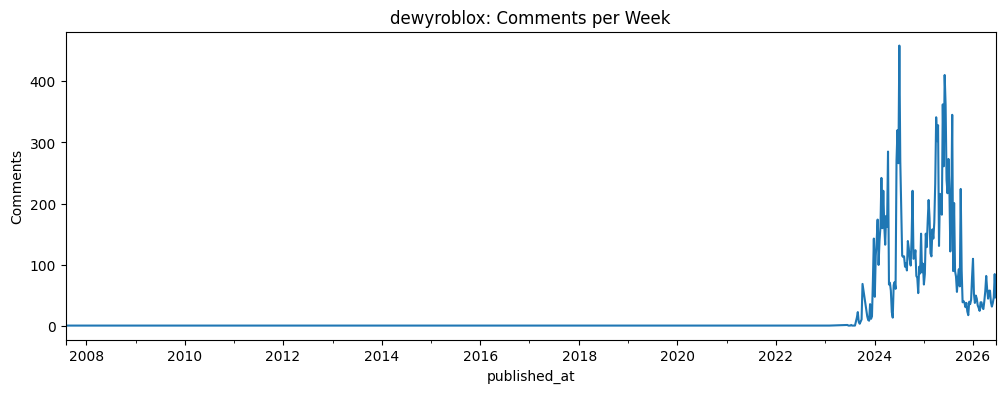

Weekly Comment Statistics
Mean:     84.19
Median:   35.00
Min:      1
Max:      988
Std Dev:  137.46


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


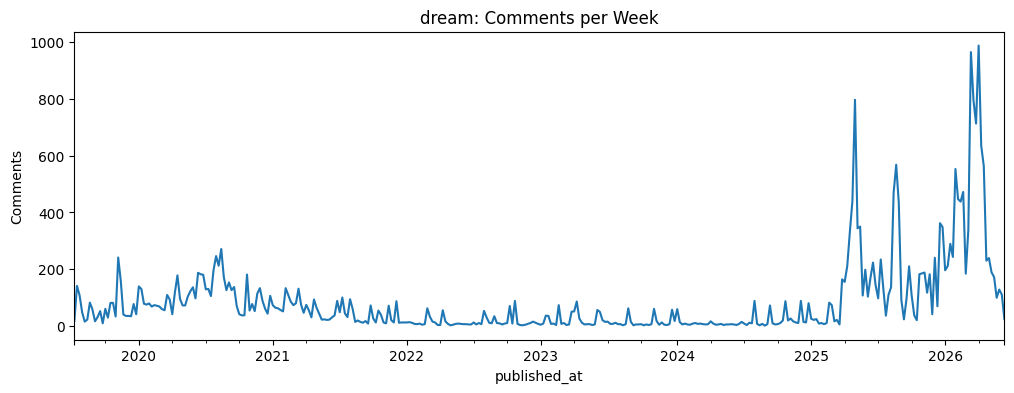

Weekly Comment Statistics
Mean:     42.29
Median:   25.50
Min:      1
Max:      248
Std Dev:  43.08


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


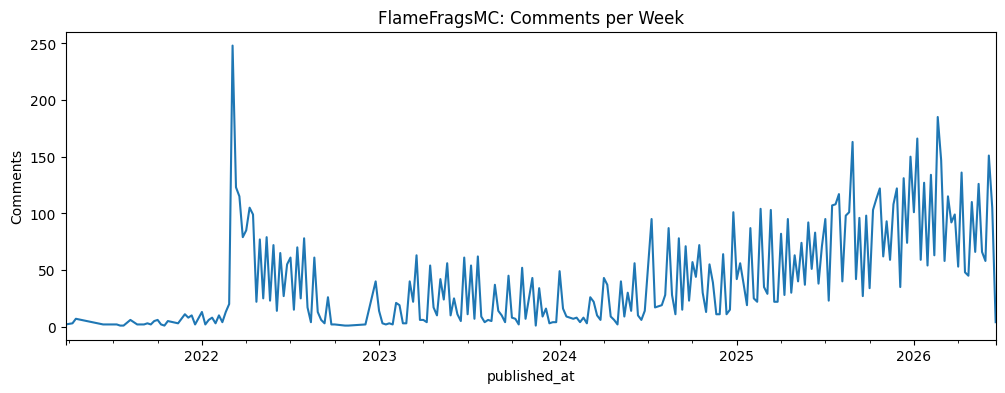

Weekly Comment Statistics
Mean:     319.99
Median:   301.00
Min:      41
Max:      1583
Std Dev:  199.59


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


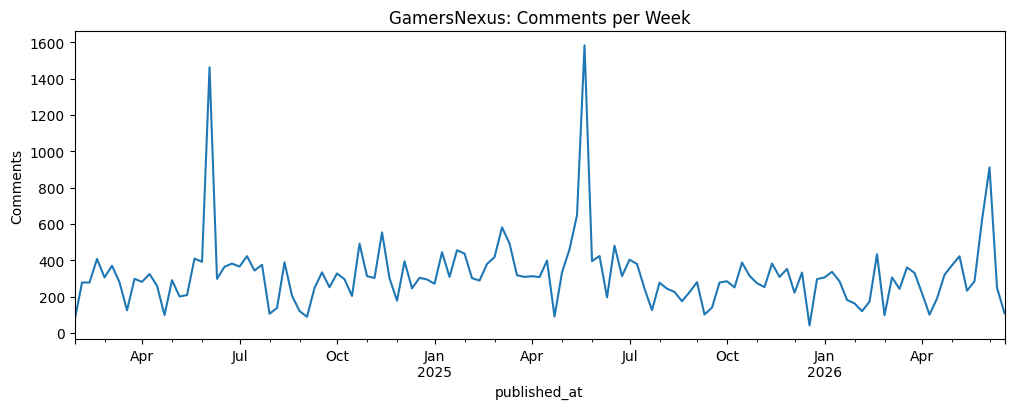

Weekly Comment Statistics
Mean:     118.23
Median:   110.00
Min:      1
Max:      1057
Std Dev:  89.40


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


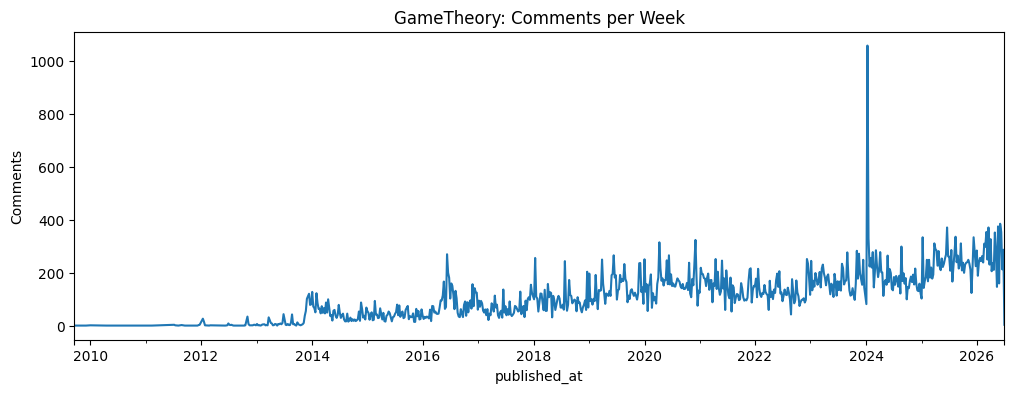

Weekly Comment Statistics
Mean:     169.70
Median:   54.50
Min:      3
Max:      663
Std Dev:  258.10


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


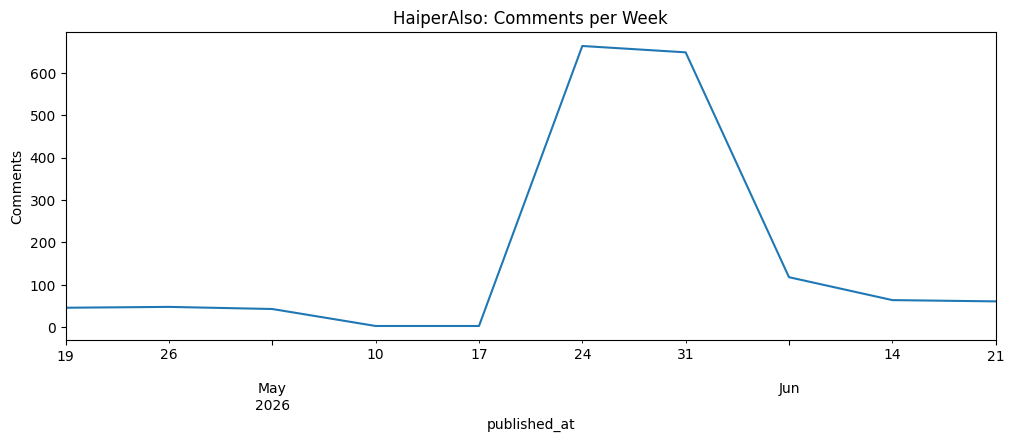

Weekly Comment Statistics
Mean:     441.59
Median:   412.00
Min:      63
Max:      1476
Std Dev:  247.47


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


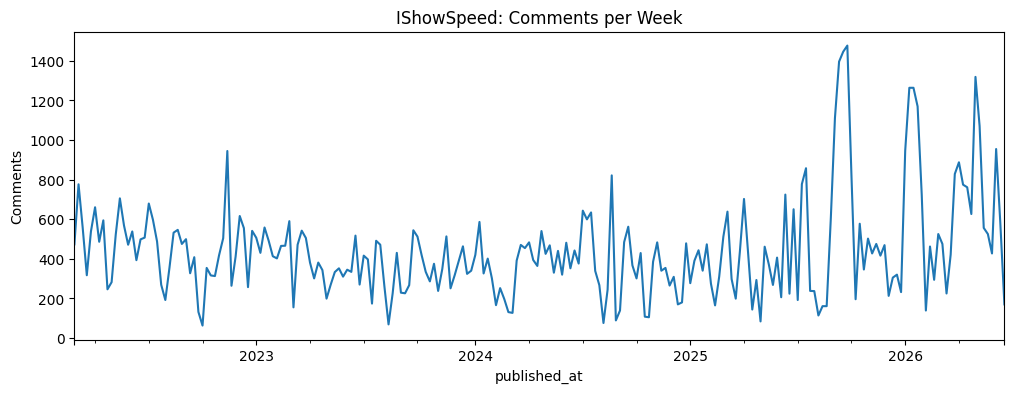

Weekly Comment Statistics
Mean:     238.51
Median:   224.00
Min:      5
Max:      722
Std Dev:  117.87


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


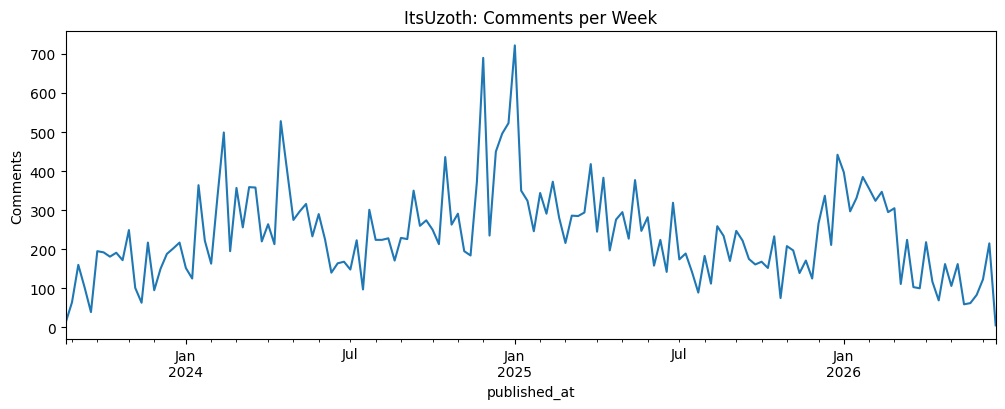

Weekly Comment Statistics
Mean:     559.97
Median:   497.00
Min:      73
Max:      1498
Std Dev:  296.23


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


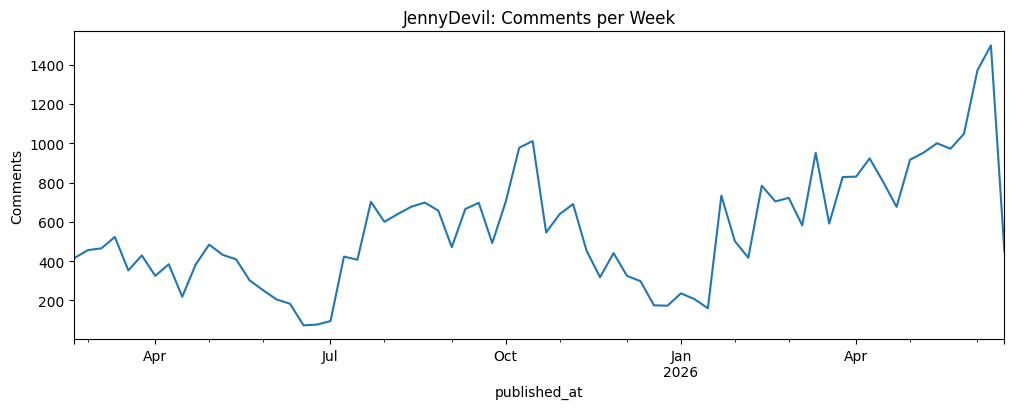

Weekly Comment Statistics
Mean:     2330.14
Median:   2483.50
Min:      515
Max:      2963
Std Dev:  583.65


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


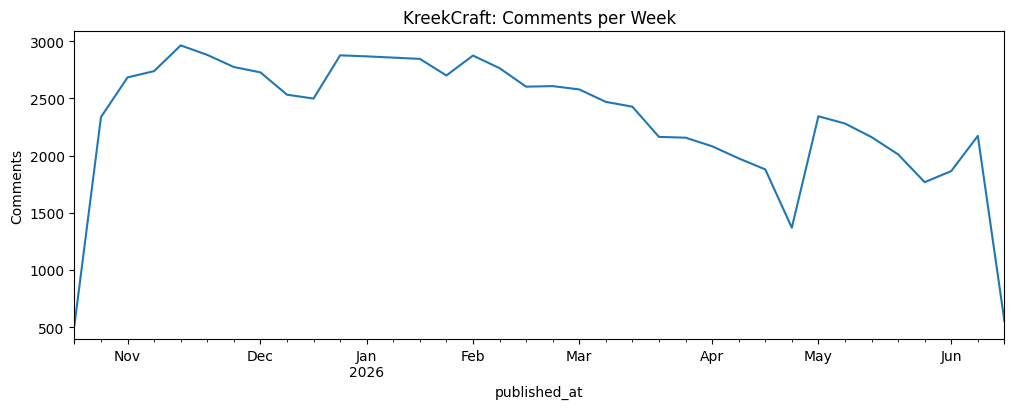

Weekly Comment Statistics
Mean:     444.57
Median:   490.00
Min:      62
Max:      814
Std Dev:  249.19


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


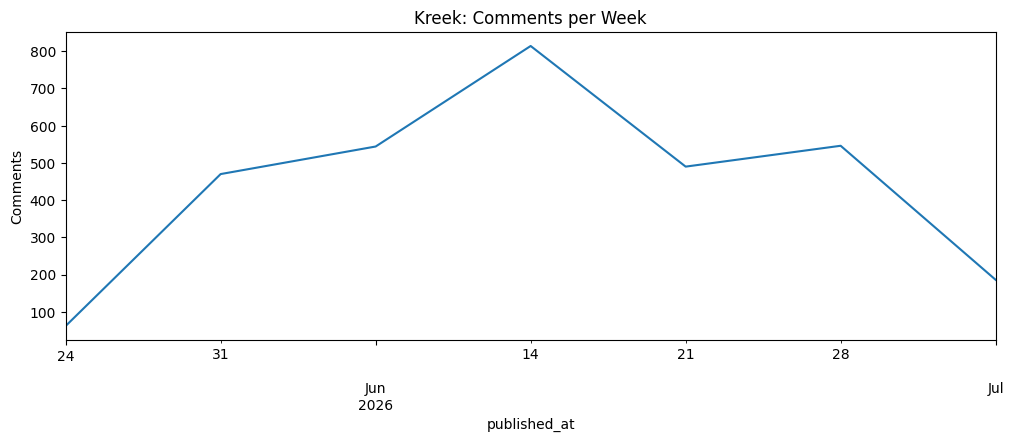

C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


Weekly Comment Statistics
Mean:     190.70
Median:   138.00
Min:      1
Max:      925
Std Dev:  165.28


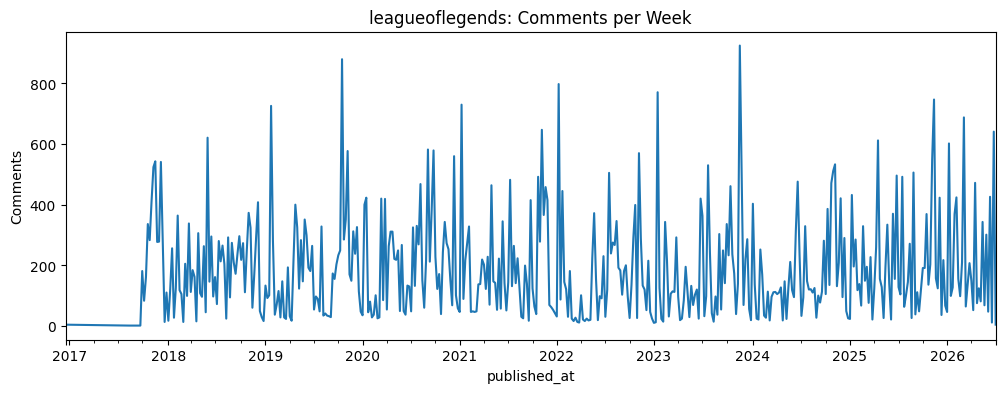

Weekly Comment Statistics
Mean:     326.13
Median:   348.00
Min:      15
Max:      777
Std Dev:  164.40


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


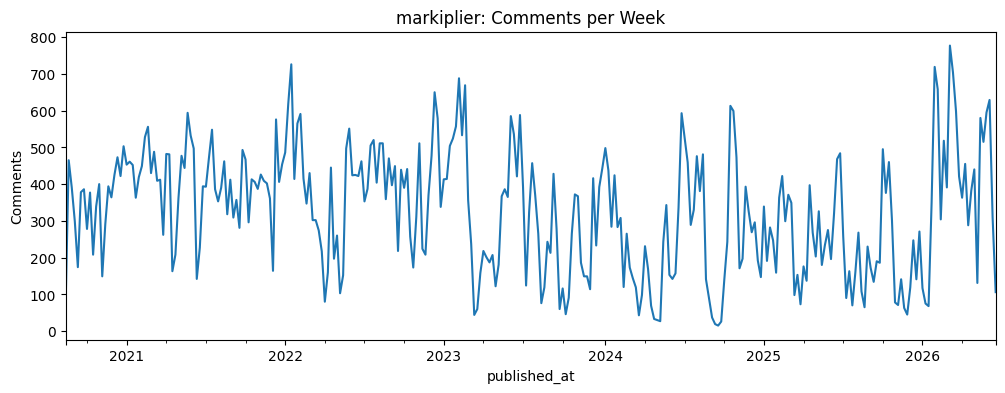

Weekly Comment Statistics
Mean:     8.78
Median:   3.00
Min:      1
Max:      138
Std Dev:  16.81


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


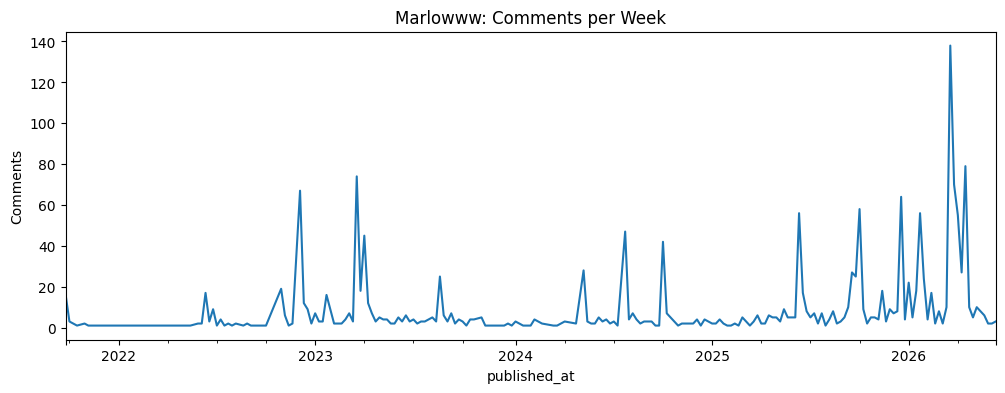

C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


Weekly Comment Statistics
Mean:     55.02
Median:   27.00
Min:      3
Max:      255
Std Dev:  55.48


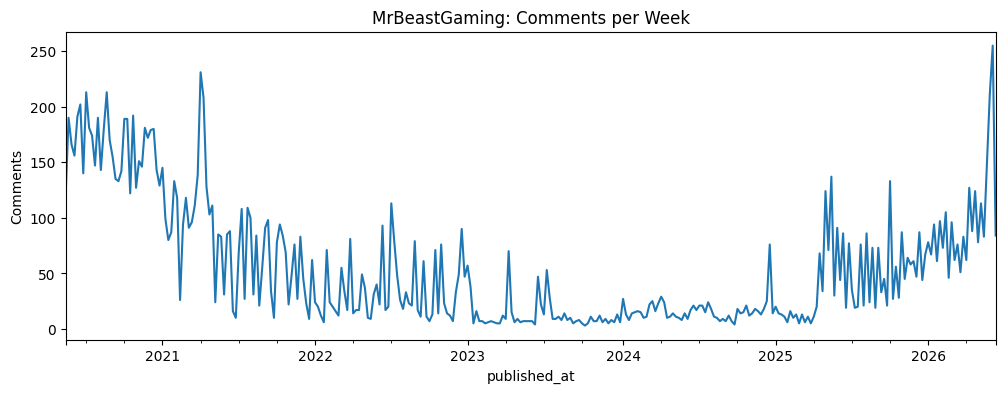

Weekly Comment Statistics
Mean:     495.02
Median:   537.00
Min:      6
Max:      709
Std Dev:  133.80


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


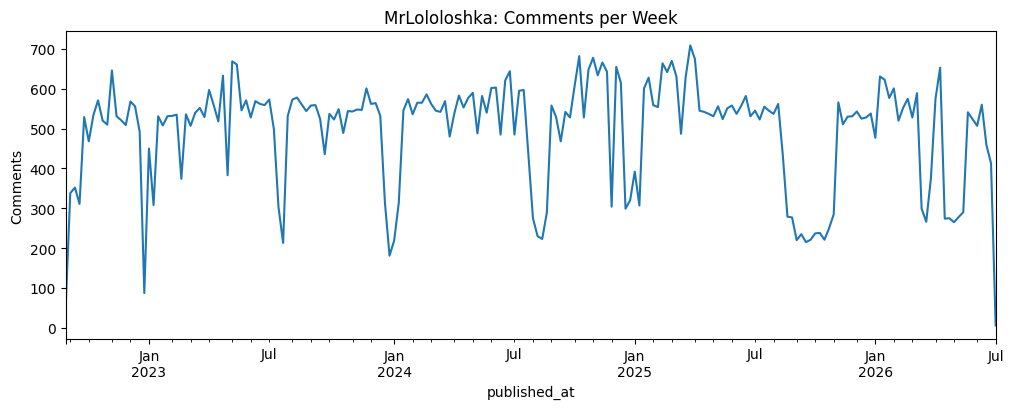

Weekly Comment Statistics
Mean:     932.24
Median:   793.00
Min:      11
Max:      4815
Std Dev:  708.52


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


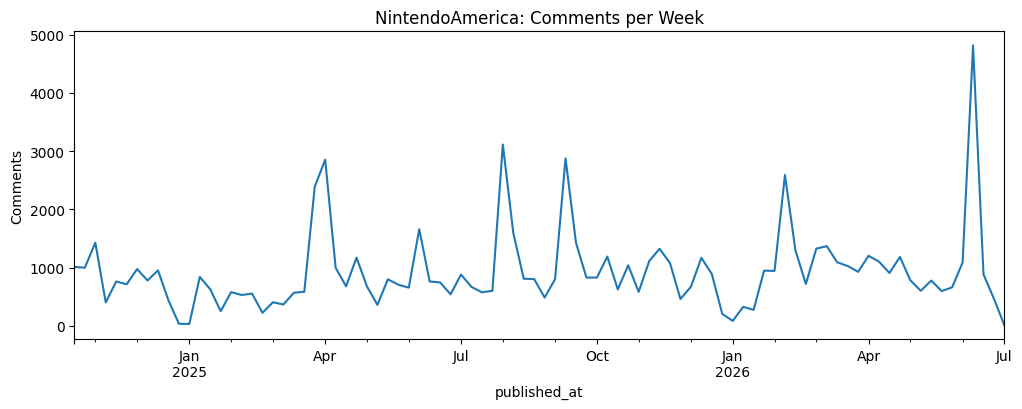

Weekly Comment Statistics
Mean:     34.34
Median:   17.50
Min:      1
Max:      259
Std Dev:  40.66


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


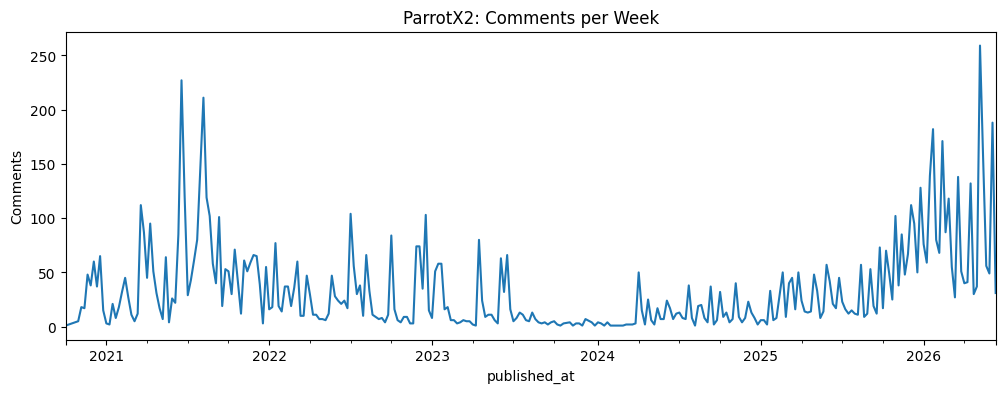

Weekly Comment Statistics
Mean:     1455.15
Median:   1464.00
Min:      269
Max:      1887
Std Dev:  223.39


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


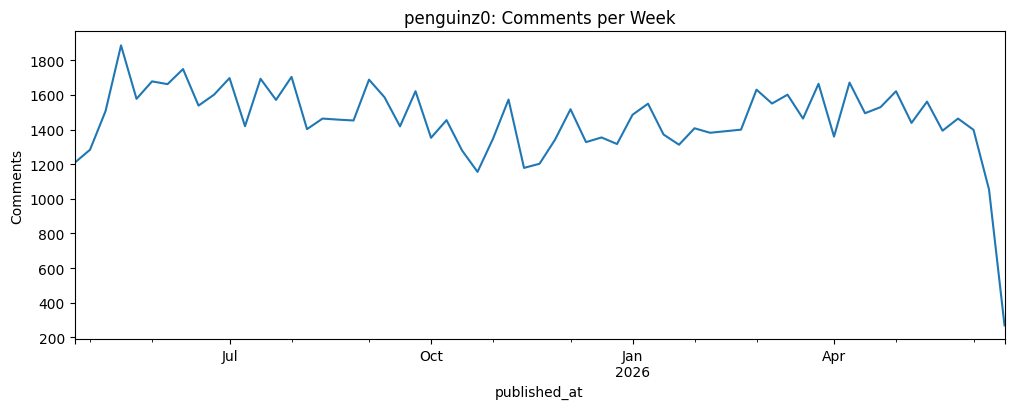

Weekly Comment Statistics
Mean:     3115.38
Median:   2932.00
Min:      336
Max:      9879
Std Dev:  1878.68


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


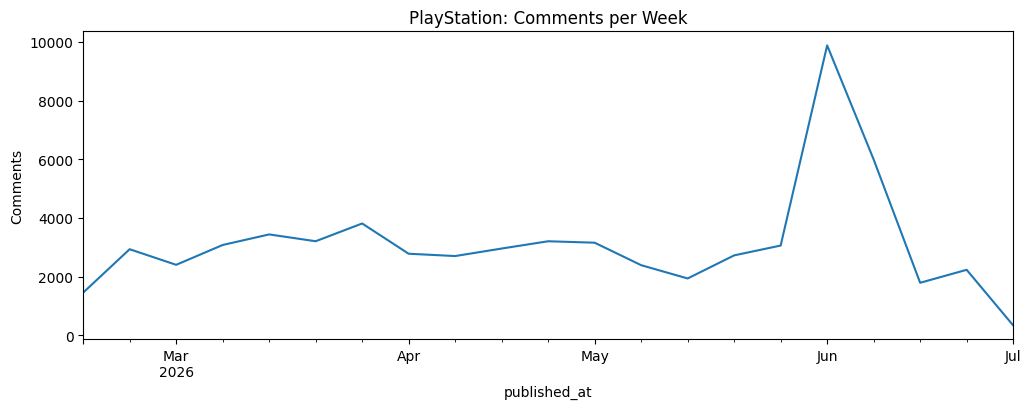

Weekly Comment Statistics
Mean:     43.23
Median:   22.00
Min:      1
Max:      397
Std Dev:  52.79


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


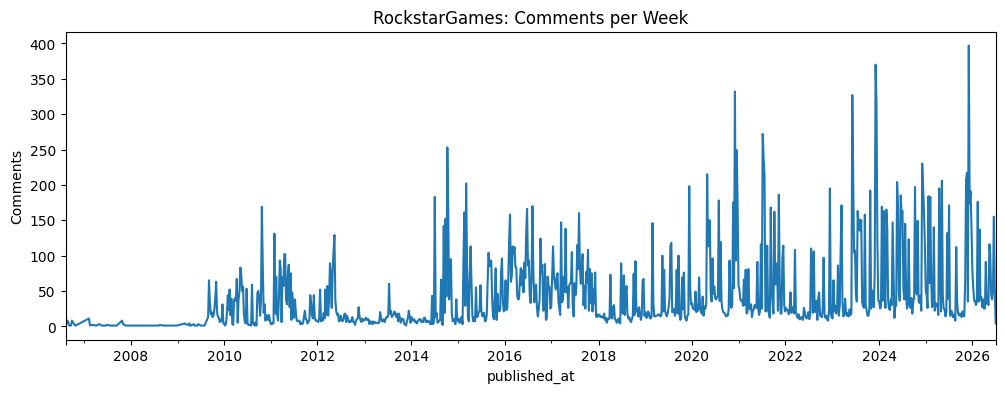

Weekly Comment Statistics
Mean:     36.91
Median:   16.00
Min:      1
Max:      369
Std Dev:  48.14


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


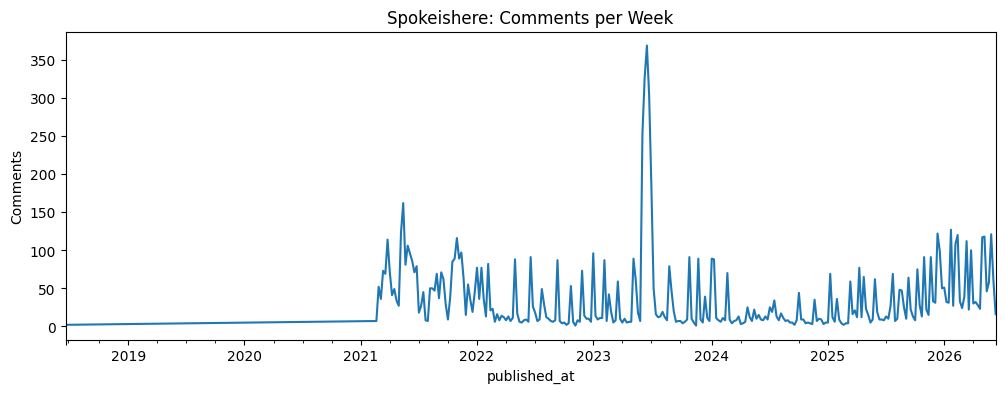

Weekly Comment Statistics
Mean:     131.76
Median:   79.00
Min:      1
Max:      4718
Std Dev:  226.28


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


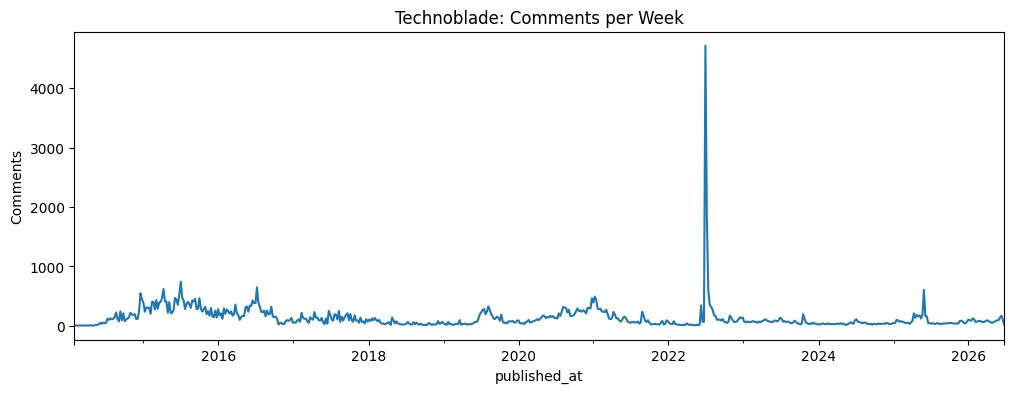

Weekly Comment Statistics
Mean:     64.49
Median:   35.00
Min:      1
Max:      384
Std Dev:  74.30


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


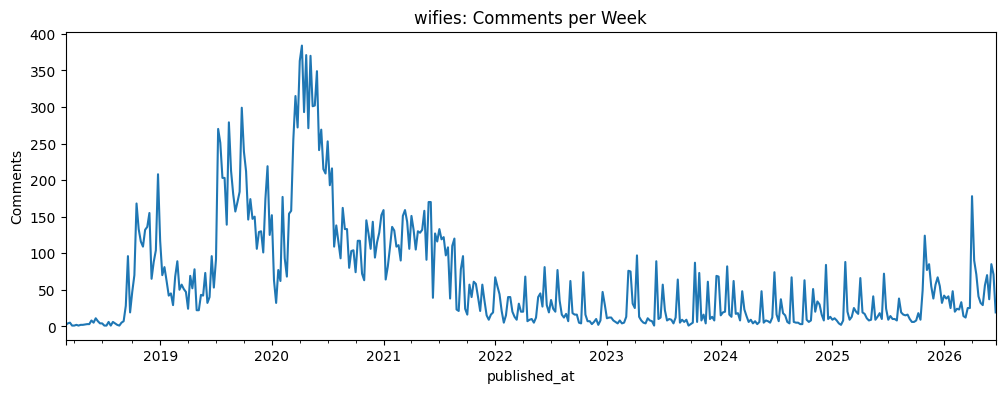

Weekly Comment Statistics
Mean:     1458.86
Median:   1473.00
Min:      196
Max:      2420
Std Dev:  388.96


C:\Users\Jamie\AppData\Local\Temp\ipykernel_22500\327347222.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))


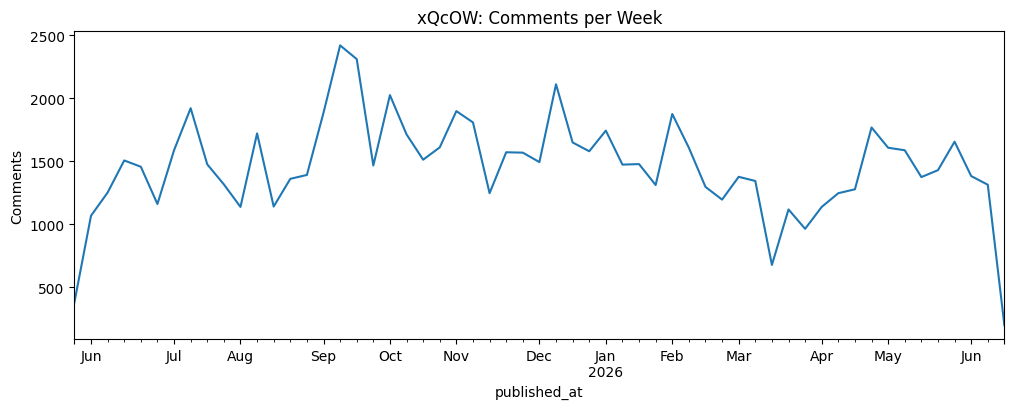

In [20]:
for channel in df.channel.unique():
    weekly_counts = (
    df[df.channel == channel].groupby(df[df.channel == channel]["published_at"].dt.to_period("W"))
      .size()
    )

    print("Weekly Comment Statistics")
    print(f"Mean:     {weekly_counts.mean():.2f}")
    print(f"Median:   {weekly_counts.median():.2f}")
    print(f"Min:      {weekly_counts.min()}")
    print(f"Max:      {weekly_counts.max()}")
    print(f"Std Dev:  {weekly_counts.std():.2f}")


    weekly_counts.plot(figsize=(12,4))
    plt.title(channel+": Comments per Week")
    plt.ylabel("Comments")
    plt.show()

I decided to check the oldest video on each channel (this is only on Youtube and for videos that are still up today (and I didn't check the Live or Shorts sections)
1STUD: 3/1/2022
AsmonTV: 12/10/2019
Aztecross: 11/27/2014 (this doesn't have a lot of views though)
BandaiNamcoAmerica: 1/11/2011
CallofDuty: 6/20/2008
CaptainSparklez: 7/23/2010
CoryxKenshin: 5/25/2009 (oldest gaming video looks to be 10/24/2013)
dewyroblox: 5/25/2006 (but takes a LONG break, comes back in 8/27/2023)
dream: 7/6/2019
FlameFragsMC: 3/5/2021
GamersNexus: 5/11/2009
GameTheory: 8/23/2009 (actual proper start is 4/14/2011)
HaiperAlso: 4/12/2026 (this person has <25k subscibers, which makes him much less popular (on Youtube at least) than most of the rest on this list I have seen so far)
IShowSpeed: 12/20/2017
ItsUzoth: 8/25/2023
JennyDevil: 1/31/2018
KreekCraft: 4/10/2014
Kreek: 5/22/2026 (this appears to be a second channel to KreekCraft that has very few videos, maybe we should combine it with the previous one?)
leagueoflegends: 2/25/2009
markiplier: 5/26/2012
Marlowww: 9/20/2021
MrBeastGaming: 5/12/2020 (this is a second channel to the much more popular main MrBeast channel)
MrLololoshka: 5/29/2012
NintendoAmerica: 1/25/2011
ParrotX2: 8/26/2020
penguinz0: 8/5/2007
PlayStation: 10/3/2008
RockstarGames: 8/11/2006
Spokeishere: 6/19/2018 (next video which is much more popular is 2/19/2021)
Technoblade: 10/31/2013 (earliest videos have low views. He died in June 2022 (this appears to be the reason for the spike of comments on that date), but there are some more recent videos uploaded by others)
wifies: 3/4/2018 (oldest videos are not popular)
xQcOW: 6/1/2016

In [27]:
for channel in df.channel.unique():
    print("First comment from "+channel+" at: "+str(df[df.channel == channel].published_at.min()))

First comment from 1STUD at: 2023-01-25 12:02:37+00:00
First comment from AsmonTV at: 2025-08-22 20:27:31+00:00
First comment from Aztecross at: 2026-03-15 19:03:58+00:00
First comment from BandaiNamcoAmerica at: 2025-10-23 16:02:08+00:00
First comment from CallofDuty at: 2024-02-05 18:00:54+00:00
First comment from CaptainSparklez at: 2019-05-07 22:00:50+00:00
First comment from CoryxKenshin at: 2015-07-23 23:30:22+00:00
First comment from dewyroblox at: 2007-07-30 20:22:08+00:00
First comment from dream at: 2019-07-12 17:10:47+00:00
First comment from FlameFragsMC at: 2021-03-23 22:50:51+00:00
First comment from GamersNexus at: 2024-02-03 22:58:05+00:00
First comment from GameTheory at: 2009-09-14 18:19:11+00:00
First comment from HaiperAlso at: 2026-04-13 02:37:08+00:00
First comment from IShowSpeed at: 2022-02-24 04:47:07+00:00
First comment from ItsUzoth at: 2023-08-26 03:38:51+00:00
First comment from JennyDevil at: 2025-02-18 19:29:12+00:00
First comment from KreekCraft at: 2025

Channels that seem problematic to me:
AsmonTV - Was popular much longer than the timeframe we have, and releases videos at a very rapid rate (3 in the last day alone as of writing this), which might make him overrepresented compared to how relevant he really is (4.62 million subscribers)
Aztecross - Similar reasons as with AsmonTV, but less severe
GamersNexus - popular for longer
JennyDevil - Popular for longer
KreekCraft - popular for longer
markiplier - popular for longer
MrLololoshka - popular for longer
penguinz0 - popular for longer
xQcOW - popular for longer
Basically all corporate channels have earlier comments not counted here

In [6]:
timegroups = df.groupby(pd.Grouper(key = 'published_at',freq = '1W'))
timegroups.groups

{Timestamp('2018-06-24 00:00:00+0000', tz='UTC'): np.int64(2),
 Timestamp('2018-07-01 00:00:00+0000', tz='UTC'): np.int64(2),
 Timestamp('2018-07-08 00:00:00+0000', tz='UTC'): np.int64(2),
 Timestamp('2018-07-15 00:00:00+0000', tz='UTC'): np.int64(2),
 Timestamp('2018-07-22 00:00:00+0000', tz='UTC'): np.int64(2),
 Timestamp('2018-07-29 00:00:00+0000', tz='UTC'): np.int64(2),
 Timestamp('2018-08-05 00:00:00+0000', tz='UTC'): np.int64(2),
 Timestamp('2018-08-12 00:00:00+0000', tz='UTC'): np.int64(83),
 Timestamp('2018-08-19 00:00:00+0000', tz='UTC'): np.int64(279),
 Timestamp('2018-08-26 00:00:00+0000', tz='UTC'): np.int64(793),
 Timestamp('2018-09-02 00:00:00+0000', tz='UTC'): np.int64(1143),
 Timestamp('2018-09-09 00:00:00+0000', tz='UTC'): np.int64(1299),
 Timestamp('2018-09-16 00:00:00+0000', tz='UTC'): np.int64(1523),
 Timestamp('2018-09-23 00:00:00+0000', tz='UTC'): np.int64(1614),
 Timestamp('2018-09-30 00:00:00+0000', tz='UTC'): np.int64(1794),
 Timestamp('2018-10-07 00:00:00+000

In [81]:
def RelativeFrequency(dfcomment, word):
    RelFreqList = []
    timegroups = dfcomment.groupby(pd.Grouper(key = 'published_at',freq = '1W'))
    for timeframe, group in timegroups: #I used Claude here to fix an error in my code
        if len(group) != 0:
            RelFreqList += [group.tokens.map(lambda x: word in x).sum() #This counts how many comments have this word in them
                  /len(group)]
        else:
            RelFreqList += [np.nan]
    return RelFreqList

In [86]:
def MeanLikes(dfcomment, word):
    MeanLikeList = []
    timegroups = dfcomment.groupby(pd.Grouper(key = 'published_at',freq = '1W'))
    for timeframe, group in timegroups:
        if group.tokens.map(lambda x: word in x).sum() != 0:
            MeanLikeList += [group.loc[group.tokens.map(lambda x: word in x)].likes.mean()] #This gives the mean number of likes of comments with this word in them in this timeframe
        else:
            MeanLikeList += [np.nan]
    return MeanLikeList

In [104]:
def NumChannels(dfcomment, word):
    NumChannelsList = []
    timegroups = dfcomment.groupby(pd.Grouper(key = 'published_at',freq = '1W'))
    for timeframe, group in timegroups:
        NumChannelsList+= [len(group.loc[group.tokens.map(lambda x: word in x)].channel.unique())]
    return NumChannelsList

In [105]:
NumChannels(df,'67')

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [87]:
MeanLikes(df, 'the')

[np.float64(780.0),
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 np.float64(407.10526315789474),
 np.float64(473.33846153846156),
 np.float64(252.92820512820512),
 np.float64(262.1682242990654),
 np.float64(562.3541666666666),
 np.float64(233.54285714285714),
 np.float64(414.89285714285717),
 np.float64(323.3235294117647),
 np.float64(1176.8157894736842),
 np.float64(518.5555555555555),
 np.float64(393.0),
 np.float64(5376.5),
 np.float64(1361.078431372549),
 np.float64(85.75),
 np.float64(625.75),
 np.float64(168.5),
 np.float64(150.5),
 np.float64(207.28571428571428),
 np.float64(353.5),
 np.float64(935.8823529411765),
 np.float64(111.25),
 np.float64(210.33333333333334),
 np.float64(483.57142857142856),
 np.float64(314.85714285714283),
 np.float64(373.546875),
 np.float64(484.88392857142856),
 np.float64(695.3218390804598),
 np.float64(326.3863636363636),
 np.float64(571.4227642276422),
 np.float64(794.3333333333334),
 np.float64(572.8187919463087),
 np.float64(638.6178343949044),
 np.float

In [82]:
RelativeFrequency(df,'the')

[np.float64(0.5),
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 np.float64(0.2345679012345679),
 np.float64(0.33163265306122447),
 np.float64(0.37937743190661477),
 np.float64(0.3057142857142857),
 np.float64(0.3076923076923077),
 np.float64(0.3125),
 np.float64(0.3076923076923077),
 np.float64(0.37777777777777777),
 np.float64(0.30158730158730157),
 np.float64(0.32142857142857145),
 np.float64(0.44776119402985076),
 np.float64(0.3333333333333333),
 np.float64(0.3248407643312102),
 np.float64(0.13793103448275862),
 np.float64(0.4444444444444444),
 np.float64(0.3333333333333333),
 np.float64(0.19047619047619047),
 np.float64(0.2916666666666667),
 np.float64(0.24242424242424243),
 np.float64(0.44155844155844154),
 np.float64(0.25),
 np.float64(0.2),
 np.float64(0.3684210526315789),
 np.float64(0.4375),
 np.float64(0.33507853403141363),
 np.float64(0.3076923076923077),
 np.float64(0.3625),
 np.float64(0.35129740518962077),
 np.float64(0.33153638814016173),
 np.float64(0.3681462140992167),
 np.floa

,video_id,text,likes,published_at,channel,tokens
0,hOZd3wF0i7I,"""They targeted me because of my race!""\n\n*Bla...",746,2026-06-08 19:06:39+00:00,AsmonTV,"[they, targeted, me, because, of, my, race, bl..."
1,hOZd3wF0i7I,this lady was a dlc character for concord 🤣,776,2026-06-08 19:14:09+00:00,AsmonTV,"[this, lady, was, a, dlc, character, for, conc..."
2,hOZd3wF0i7I,"""They axed me""\n\nThe fatigue man",246,2026-06-08 20:27:18+00:00,AsmonTV,"[they, axed, me, the, fatigue, man]"
3,hOZd3wF0i7I,Noticing Patterns fatigue,1802,2026-06-08 18:01:40+00:00,AsmonTV,"[noticing, patterns, fatigue]"
4,hOZd3wF0i7I,"""When you get used to preferential treatment, ...",1209,2026-06-08 18:17:17+00:00,AsmonTV,"[when, you, get, used, to, preferential, treat..."
...,...,...,...,...,...,...
43676,PvZoiLTYeHQ,"i boinked my robot, hopefully the assistant co...",0,2025-10-31 09:11:29+00:00,xQcOW,"[i, boinked, my, robot, hopefully, the, assist..."
43677,PvZoiLTYeHQ,You gotta remember they did 10 takes of each o...,0,2025-10-30 17:45:49+00:00,xQcOW,"[you, gotta, remember, they, did, 10, takes, o..."
43678,PvZoiLTYeHQ,oh the cloth look is so creepy and awful like ...,0,2025-10-30 16:33:53+00:00,xQcOW,"[oh, the, cloth, look, is, so, creepy, and, aw..."
43679,PvZoiLTYeHQ,you can try,0,2025-10-30 17:04:02+00:00,xQcOW,"[you, can, try]"


In [66]:
df.loc[2]

,video_id,text,likes,published_at,channel,tokens
2,hOZd3wF0i7I,"""They axed me""\n\nThe fatigue man",246,2026-06-08 20:27:18+00:00,AsmonTV,"[they, axed, me, the, fatigue, man]"
2,E91hRBbJObI,Spooky scary someday,714,2026-06-06 09:51:34+00:00,CoryxKenshin,"[spooky, scary, someday]"
2,G9I2qfuXIIg,Minecraft is looking a little realistic today...,5478,2026-05-11 13:05:30+00:00,dream,"[minecraft, is, looking, a, little, realistic,..."
2,UnFIrVKA9Zc,I Ragebaited the Cindercrest,25140,2026-06-01 04:12:08+00:00,FlameFragsMC,"[i, ragebaited, the, cindercrest]"
2,tALs77Qv7Jw,Best green apple ending 🤣,251,2026-06-07 18:17:34+00:00,IShowSpeed,"[best, green, apple, ending]"
2,SL8FEy8Wz6s,We got moms playing rblx all before gta6 😭,466,2026-05-10 02:26:22+00:00,ItsUzoth,"[we, got, moms, playing, rblx, all, before, gta6]"
2,15mR4-qIbUk,"""They lied to me"" The lunged man said as the p...",2821,2026-06-08 16:22:07+00:00,markiplier,"[they, lied, to, me, the, lunged, man, said, a..."
2,5F5MKI_jXJw,Darius’s dedication to learn and help is proba...,20382,2026-06-06 16:29:25+00:00,MrBeastGaming,"[darius, s, dedication, to, learn, and, help, ..."
2,NT2Is90lFoI,"Cindercrest : no food for old players, we have...",3562,2026-06-03 21:32:10+00:00,ParrotX2,"[cindercrest, no, food, for, old, players, we,..."
2,haX-hC7Tfdc,"The real atrocity is calling it ""SoundMojo"" an...",726,2026-06-08 19:36:04+00:00,penguinz0,"[the, real, atrocity, is, calling, it, soundmo..."


In [24]:
df.sort_values(by=["published_at"], ascending=False)

,video_id,text,likes,published_at,channel,tokens
34911,kzA-ilEC5Rg,He not sneaky with the voice crack 4:10,0,2026-06-09 01:03:06+00:00,CoryxKenshin,"[he, not, sneaky, with, the, voice, crack, 4, 10]"
9601,d2By2FhgY0U,mystic pull,0,2026-06-09 00:58:25+00:00,ParrotX2,"[mystic, pull]"
11833,1OZqvprj_Rk,"CoryxKenshin, I miss you, bro 0:59",0,2026-06-09 00:57:27+00:00,CoryxKenshin,"[coryxkenshin, i, miss, you, bro, 0, 59]"
9281,cB-dUnpmJgc,At first I thought this was a temp version of ...,0,2026-06-09 00:55:49+00:00,ParrotX2,"[at, first, i, thought, this, was, a, temp, ve..."
17651,nJ2GVUf_chg,When does venom rework come out😢,1,2026-06-09 00:52:42+00:00,ItsUzoth,"[when, does, venom, rework, come, out]"
...,...,...,...,...,...,...
49857,rGEEhbMVsn4,This game looks great,31,2018-08-09 21:06:24+00:00,CoryxKenshin,"[this, game, looks, great]"
49788,rGEEhbMVsn4,I spent WAYY too much money making this... yehh..,8722,2018-08-09 21:04:05+00:00,CoryxKenshin,"[i, spent, wayy, too, much, money, making, thi..."
49879,rGEEhbMVsn4,You’re so cool cory,30,2018-08-09 21:04:03+00:00,CoryxKenshin,"[you, re, so, cool, cory]"
10273,yH_YuFAGYCU,good content just use a catchy thumbnail,24,2018-06-22 18:35:06+00:00,Spokeishere,"[good, content, just, use, a, catchy, thumbnail]"
